# SDM in Python

Some features based on https://github.com/daniel-furman/eco-distribution-mapping/blob/main/Python-sdm.ipynb

### Making subdirectories
inputs - files input for processing   
outputs - results from processing

In [1]:
import os
os.mkdir("inputs")
os.mkdir("outputs")

### Converting shapefiles (.shp) to geopandas dataframe

In [2]:
import geopandas as gpd
import shutil
import glob

# for f in sorted(glob.glob('data/ncr*')):
#     shutil.copy(f, 'inputs/')

ncr_gdf = gpd.GeoDataFrame.from_file('data/ncr.shp')
ncr_gdf.sample(5)

,CLASS,geometry
993,1.0,POINT (-88.68259 42.71996)
531,1.0,POINT (-96.56246 40.84548)
485,1.0,POINT (-88.3282 42.1654)
255,1.0,POINT (-88.99088 41.23979)
879,1.0,POINT (-88.89428 42.32604)


Checking duplicates and NA values. Coordinate reference system should ideally be epsg: 4326

In [3]:
print("Number of duplicates: ", ncr_gdf.duplicated(subset='geometry', keep='first').sum())
print("Number of NA's: ", ncr_gdf['geometry'].isna().sum())
print("Coordinate reference system: {}".format(ncr_gdf.crs))
print("{} observations with {} columns".format(*ncr_gdf.shape))

Number of duplicates:  0
Number of NA's:  0
Coordinate reference system: GEOGCS["unknown",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
1442 observations with 2 columns


Mapping the species presences (pa == 1)

<Axes: >

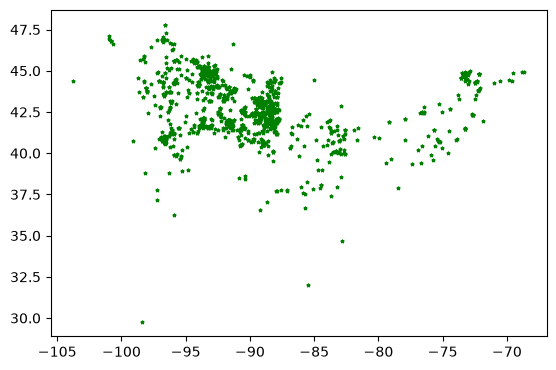

In [4]:
ncr_gdf[ncr_gdf.CLASS == 1].plot(marker='*', color='green', markersize=5)

Mapping the species absences (pa == 0)

<Axes: >

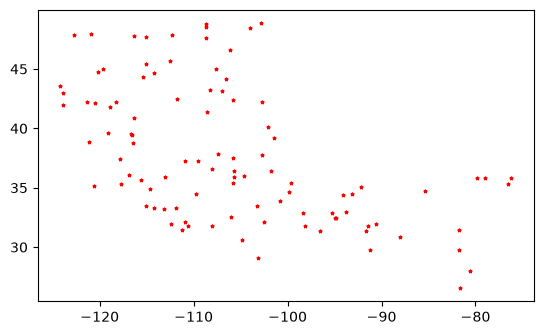

In [6]:
ncr_gdf[ncr_gdf.CLASS == 0].plot(marker='*', color='red', markersize=5)

### Classifier Training

In [7]:
# TO MOVE FILES INTO INPUT
# for f in sorted(glob.glob('worldclim/wc2.1_2.5m_bio_*.tif')):
#     shutil.copy(f,'inputs/')

ras_feats = sorted(glob.glob(
    'worldclim/wc2.1_2.5m_bio_*.tif'))

print('There are ', len(ras_feats), ' raster features.')


There are  7  raster features.


Generate raster maps of suitability

In [8]:
from pyimpute import load_training_vector
from pyimpute import load_targets

train_xs, train_y = load_training_vector(ncr_gdf, ras_feats, response_field='CLASS')
target_xs, raster_info = load_targets(ras_feats)
train_xs.shape, train_y.shape

((1442, 7), (1442,))

Classifier implementation

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

CLASS_MAP = {
    'rf': (RandomForestClassifier()),
    'et': (ExtraTreesClassifier()),
    'xgb': (XGBClassifier()),
    'lgbm': (LGBMClassifier())
}

from pyimpute import impute
from sklearn import model_selection

